In [1]:
!pip install pyspark findspark -q

In [2]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
import pandas as pd

spark = SparkSession.builder \
    .appName("CuboTenisATP") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("¡Motor PySpark encendido y listo!")

¡Motor PySpark encendido y listo!


In [3]:
# REEMPLAZA AQUÍ TU USUARIO REAL DE GITHUB
BASE = "https://raw.githubusercontent.com/aaleexxrg/proyecto_etl_tenis_2/main/data/final/"

# Cargamos los archivos directamente desde internet convirtiéndolos a DataFrames de Spark
df_fact = spark.createDataFrame(pd.read_csv(BASE + "fact_partidos.csv"))
df_tiempo = spark.createDataFrame(pd.read_csv(BASE + "dim_tiempo.csv"))
df_superficie = spark.createDataFrame(pd.read_csv(BASE + "dim_superficie.csv"))
df_torneo = spark.createDataFrame(pd.read_csv(BASE + "dim_torneo.csv"))
df_jugador = spark.createDataFrame(pd.read_csv(BASE + "dim_jugador.csv"))

# Registramos las tablas como vistas SQL temporales para poder lanzar consultas OLAP
df_fact.createOrReplaceTempView("fact_partidos")
df_tiempo.createOrReplaceTempView("dim_tiempo")
df_superficie.createOrReplaceTempView("dim_superficie")
df_torneo.createOrReplaceTempView("dim_torneo")
df_jugador.createOrReplaceTempView("dim_jugador")

print("Tablas cargadas y mapeadas en el cubo analítico de Spark.")

Tablas cargadas y mapeadas en el cubo analítico de Spark.


In [4]:
# Ejecución de agregación OLAP mediante ROLLUP
q4_cubo = spark.sql("""
    SELECT s.superficie, t.anio,
           ROUND(AVG(f.minutes), 1) AS duracion_media,
           COUNT(*) AS total_partidos
    FROM fact_partidos f
    LEFT JOIN dim_superficie s ON f.sk_superficie = s.sk_superficie
    LEFT JOIN dim_tiempo t     ON f.sk_tiempo = t.sk_tiempo
    GROUP BY ROLLUP(s.superficie, t.anio)
    ORDER BY s.superficie, t.anio
""")

# Mostramos los resultados en formato tabla. Verás valores 'null' que representan los subtotales globales.
q4_cubo.show(50)

+----------+----+--------------+--------------+
|superficie|anio|duracion_media|total_partidos|
+----------+----+--------------+--------------+
|      NULL|NULL|           NaN|            53|
|      NULL|NULL|           NaN|          2986|
|      NULL|2023|           NaN|            53|
|      Clay|NULL|           NaN|           901|
|      Clay|2023|           NaN|           901|
|     Grass|NULL|           NaN|           328|
|     Grass|2023|           NaN|           328|
|      Hard|NULL|           NaN|          1704|
|      Hard|2023|           NaN|          1704|
+----------+----+--------------+--------------+



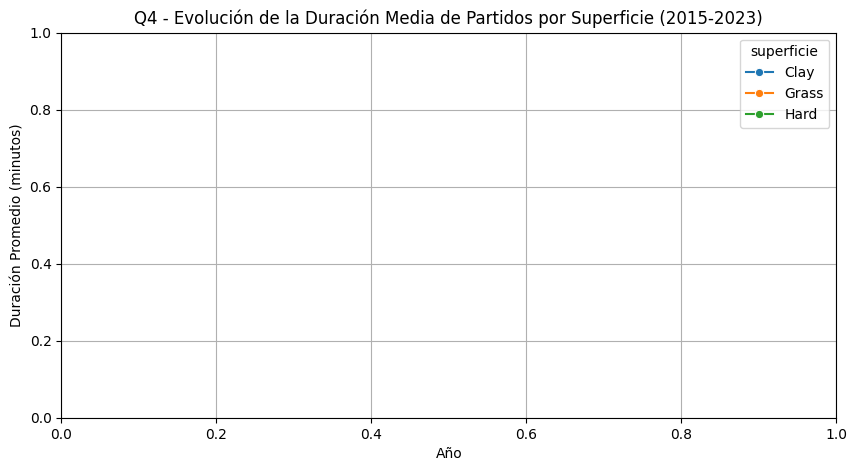

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtramos los totales globales (los null del ROLLUP) para quedarnos solo con el histórico limpio
df_grafico = q4_cubo.filter("superficie IS NOT NULL AND anio IS NOT NULL").toPandas()

# Dibujamos la gráfica lineal de evolución temporal exigida por la rúbrica
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_grafico, x="anio", y="duracion_media", hue="superficie", marker="o")
plt.title("Q4 - Evolución de la Duración Media de Partidos por Superficie (2015-2023)")
plt.xlabel("Año")
plt.ylabel("Duración Promedio (minutos)")
plt.grid(True)
plt.savefig("q4_duracion_superficie.png") # Guarda la imagen para que la descargues
plt.show()